# TP3 — KPIs par canal — Lumina & Co

**Cours :** Data Marketing et Analytics — DIA2 — HETIC
**Jour 3, notebook 1/2 :** *"Le social nous dit que tout marche très bien. Google nous dit la même chose.
Mais je m'attendais à plus de ventes."*

Le CMO reçoit des rapports contradictoires parce que chaque canal se mesure seul, dans son propre outil (Meta
Business Suite, Google Analytics…), sans base de comparaison commune. Ce notebook construit cette base commune :
CAC, CPA, ROAS et taux de conversion, calculés de la même façon pour les 7 canaux, à partir des mêmes données
(`touchpoints.csv`, `campaigns.csv`, `transactions.csv`, `customers.csv`).

**Second notebook (`TP3_Attribution.ipynb`)** : comparaison first touch vs last touch et recommandation de modèle
d'attribution — volontairement séparé de celui-ci, qui se concentre sur les KPIs bruts par canal.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 100
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

PALETTE = {
    "primary": "#5B4FCF",
    "secondary": "#2FB4A6",
    "warn": "#E0793C",
    "bad": "#D64550",
    "neutral": "#8891A5",
}
CHANNEL_ORDER = ["display", "social", "affiliate", "retargeting", "email", "search_paid", "direct"]
CHANNEL_COLORS = {
    "display": "#8891A5", "social": "#B7A8E8", "affiliate": "#5B4FCF", "retargeting": "#2FB4A6",
    "email": "#4C9BE0", "search_paid": "#E0C23C", "direct": "#E0793C",
}

## Étape 0 — Chargement et préparation

On reprend les décisions de nettoyage du Jour 1 sur `transactions.csv` (déduplication, `line_total`) pour pouvoir
calculer le revenu réel généré par chaque conversion. `touchpoints.csv` contient un point de contact par ligne
(1 080 897 lignes) : un `journey_id` regroupe tous les points de contact d'un même parcours d'achat, `channel` le
canal de ce point de contact, `converted` vaut 1 sur le point de contact qui a directement précédé l'achat.

In [2]:
touchpoints = pd.read_csv("Lumina & Co - CRM/touchpoints.csv")
campaigns = pd.read_csv("Lumina & Co - CRM/campaigns.csv")
transactions = pd.read_csv("Lumina & Co - CRM/transactions.csv")
customers = pd.read_csv("Lumina & Co - CRM/customers.csv")

touchpoints["timestamp"] = pd.to_datetime(touchpoints["timestamp"])
transactions["invoice_date"] = pd.to_datetime(transactions["invoice_date"])
customers["first_purchase"] = pd.to_datetime(customers["first_purchase"])

# reprise des décisions de nettoyage du Jour 1
transactions = transactions[~transactions.duplicated(keep="first")].reset_index(drop=True)
transactions["line_total"] = transactions["quantity"] * transactions["unit_price"]

print(f"touchpoints : {len(touchpoints):,} lignes, {touchpoints['journey_id'].nunique():,} parcours".replace(",", " "))
print(f"canaux présents : {sorted(touchpoints['channel'].unique())}")
print(f"campagnes : {list(campaigns['campaign_name'])}")

touchpoints : 1 080 897 lignes  214 897 parcours
canaux présents : ['affiliate', 'direct', 'display', 'email', 'retargeting', 'search_paid', 'social']
campagnes : ['Back_to_School', 'Black_Friday', 'Spring_Launch', 'Summer_Sale', 'Valentine', 'Winter_Promo']


**Pourquoi calculer les KPIs par canal depuis `touchpoints.csv` plutôt que depuis `campaigns.csv` ?**
`campaigns.csv` agrège les métriques **par campagne**, pas par canal — chaque campagne a un unique
`primary_channel`, mais mélange en réalité plusieurs canaux dans ses points de contact (on le vérifie plus bas).
Pour comparer les canaux entre eux, il faut donc redescendre au niveau `touchpoints.csv`, qui donne un `channel`
par ligne, et reconstruire nous-mêmes coût, conversions et revenu à cette granularité.

## Étape 1 — KPIs par canal

### Revenu généré par chaque conversion

Chaque point de contact avec `converted == 1` référence un `invoice_id`. On relie cet identifiant à
`transactions.csv` pour récupérer le revenu réel de la vente (`line_total` sommé sur toutes les lignes de la
facture), plutôt que d'utiliser une approximation.

In [3]:
invoice_revenue = transactions.groupby("invoice_id")["line_total"].sum()
invoice_date = transactions.groupby("invoice_id")["invoice_date"].min()

conversions = touchpoints[touchpoints["converted"] == 1].copy()
conversions["invoice_id"] = conversions["invoice_id"].astype(int).astype(str)
conversions["revenue"] = conversions["invoice_id"].map(invoice_revenue)
conversions["invoice_date"] = conversions["invoice_id"].map(invoice_date)

print(f"Conversions (points de contact avec converted=1) : {len(conversions):,}".replace(",", " "))
print(f"Revenu retrouvé pour {conversions['revenue'].notna().sum():,} / {len(conversions):,} conversions "
      f"({conversions['revenue'].notna().mean()*100:.1f} %)".replace(",", " "))

Conversions (points de contact avec converted=1) : 94 366
Revenu retrouvé pour 94 366 / 94 366 conversions (100.0 %)


### Repérer les primo-achats (nécessaire pour le CAC)

**CAC ≠ CPA.** Le CPA (coût par acquisition *campagne*) compte toute conversion, y compris le réachat d'un client
déjà fidèle. Le CAC (coût d'acquisition *client*) ne doit compter que les **nouveaux** clients — sinon on
confond "faire revenir quelqu'un qui achète déjà chez nous" avec "convaincre quelqu'un qui n'a jamais acheté".

Un primo-achat se repère en comparant la date de la facture de conversion à `first_purchase` du client dans
`customers.csv` : si elles sont égales, c'est le premier achat de ce client.

In [4]:
conversions = conversions.merge(customers[["customer_id", "first_purchase"]], on="customer_id", how="left")
conversions["is_first_purchase"] = conversions["invoice_date"] == conversions["first_purchase"]

pct_primo = conversions["is_first_purchase"].mean() * 100
print(f"Primo-achats parmi les conversions : {conversions['is_first_purchase'].sum():,} / {len(conversions):,} "
      f"({pct_primo:.1f} %)".replace(",", " "))

Primo-achats parmi les conversions : 1 700 / 94 366 (1.8 %)


**Seulement 1,8 % des conversions sont des primo-achats.** Cohérent avec le Jour 2 : la base est dominée par
des clients déjà connus (Champions, Fidèles, À risque…) qui repassent à l'achat, pas par de l'acquisition pure.
Ce chiffre très bas est en soi un signal : le CAC calculé plus bas va porter sur un échantillon **beaucoup plus
petit** que le CPA (quelques centaines de nouveaux clients par canal contre plusieurs milliers de conversions) —
donc mécaniquement plus instable, et son écart avec le CPA sera très large plutôt que "proche" comme le serait le
cas si le filtre primo-achat était mal posé.

### Construction du tableau de KPIs par canal

In [5]:
cost_by_channel = touchpoints.groupby("channel")["cost"].sum()
touchpoints_by_channel = touchpoints.groupby("channel").size()
clicks_by_channel = touchpoints.groupby("channel")["click"].sum()
conversions_by_channel = conversions.groupby("channel").size().reindex(cost_by_channel.index, fill_value=0)
revenue_by_channel = conversions.groupby("channel")["revenue"].sum().reindex(cost_by_channel.index, fill_value=0)
new_customers_by_channel = (
    conversions[conversions["is_first_purchase"]].groupby("channel").size()
    .reindex(cost_by_channel.index, fill_value=0)
)

kpi = pd.DataFrame({
    "cost": cost_by_channel,
    "touchpoints": touchpoints_by_channel,
    "clicks": clicks_by_channel,
    "conversions": conversions_by_channel,
    "new_customers": new_customers_by_channel,
    "revenue": revenue_by_channel,
})

kpi["CTR_%"] = kpi["clicks"] / kpi["touchpoints"] * 100
kpi["taux_conversion_%"] = kpi["conversions"] / kpi["touchpoints"] * 100
kpi["CPA"] = kpi["cost"] / kpi["conversions"]
kpi["CAC"] = kpi["cost"] / kpi["new_customers"]
kpi["ROAS"] = kpi["revenue"] / kpi["cost"]

kpi = kpi.reindex(CHANNEL_ORDER)
kpi.round(2)

,cost,touchpoints,clicks,conversions,new_customers,revenue,CTR_%,taux_conversion_%,CPA,CAC,ROAS
channel,,,,,,,,,,,
display,1482.10,316530,142192,0,0,0.00,44.92,0.00,inf,inf,0.00
social,166324.04,315763,142089,0,0,0.00,45.00,0.00,inf,inf,0.00
affiliate,1128776.74,54516,44884,26979,493,5312839.54,82.33,49.49,41.84,2289.61,4.71
retargeting,1897.65,158102,83548,22563,427,4455875.21,52.84,14.27,0.08,4.44,2348.11
email,2263.28,150733,75666,14355,252,2603316.40,50.20,9.52,0.16,8.98,1150.24
search_paid,47264.48,41334,31548,13666,259,2824604.73,76.32,33.06,3.46,182.49,59.76
direct,0.00,43919,34441,16803,269,3204530.74,78.42,38.26,0.00,0.00,inf


**Deux canaux à part : `display` et `social` n'ont ZÉRO conversion directe** — ils n'apparaissent jamais comme
le point de contact `converted=1` d'un parcours, alors qu'ils portent à eux deux **65 % du volume de points de
contact** et **12,5 % du budget total**. Leur CPA et CAC sont donc mathématiquement indéfinis (division par
zéro → `inf`), et leur ROAS tombe à 0. **Ce n'est pas un signe que ces canaux ne servent à rien** — voir la
discussion dédiée plus bas, et le notebook d'attribution.

**`direct` a un coût de 0€** (trafic non payant, pas de dépense marketing associée) : son CAC et CPA sont
mécaniquement nuls et son ROAS mécaniquement infini. Ce n'est pas non plus "le meilleur canal" au sens marketing
du terme — on ne peut pas décider d'investir davantage dans du trafic direct, ce n'est pas un levier activable
comme les autres. Ces deux artefacts (division par zéro dans un sens ou dans l'autre) sont à garder en tête pour
toute la suite de l'analyse.

### Classement des canaux selon chaque métrique

In [6]:
ranking = pd.DataFrame({
    "CAC (croissant = meilleur)": kpi["CAC"].sort_values().index,
    "CPA (croissant = meilleur)": kpi["CPA"].sort_values().index,
    "ROAS (décroissant = meilleur)": kpi["ROAS"].sort_values(ascending=False).index,
    "Taux de conversion (décroissant = meilleur)": kpi["taux_conversion_%"].sort_values(ascending=False).index,
})
ranking.index = range(1, len(ranking) + 1)
ranking.index.name = "Rang"
ranking

,CAC (croissant = meilleur),CPA (croissant = meilleur),ROAS (décroissant = meilleur),Taux de conversion (décroissant = meilleur)
Rang,,,,
1,direct,direct,direct,affiliate
2,retargeting,retargeting,retargeting,direct
3,email,email,email,search_paid
4,search_paid,search_paid,search_paid,retargeting
5,affiliate,affiliate,affiliate,email
6,display,display,display,display
7,social,social,social,social


**Le classement n'est pas du tout le même selon la métrique choisie.**

- **CAC et CPA** classent `direct` et `retargeting` en tête (coût quasi nul), et `affiliate` en dernier — son coût
  total (1,13 M€, 84 % du budget marketing total) est concentré sur très peu de conversions à primo-achat (493),
  donc un CAC très élevé (2 290 €).
- **ROAS** classe `retargeting` et `email` très largement devant les autres (coût minuscule pour un revenu non
  négligeable), et `affiliate` avant-dernier malgré un très bon taux de conversion — parce que son coût par
  conversion est élevé (modèle de rémunération à la commission, cohérent avec le rôle d'un partenaire affilié).
- **Le taux de conversion** classe `affiliate` premier (49,5 % des points de contact affiliés convertissent
  directement) et `retargeting` seulement 4ᵉ, alors que `retargeting` est le meilleur canal en ROAS.

**Pourquoi un tel écart de classement ?** Chaque métrique répond à une question différente : le CAC/CPA
répondent à *"combien ça coûte de convertir"*, le ROAS à *"combien ça rapporte pour ce qu'on dépense"*, et le
taux de conversion à *"quelle proportion de contacts se transforme"* — sans tenir compte du coût. Un canal cher
mais très efficace au contact (affiliate) et un canal quasi gratuit mais peu sollicité (retargeting) ne peuvent
pas occuper le même rang sur les deux lectures à la fois. **Aucune métrique seule ne suffit** : le CPA/CAC sans
le ROAS ignore le revenu généré, le ROAS sans le taux de conversion ignore le volume, etc.

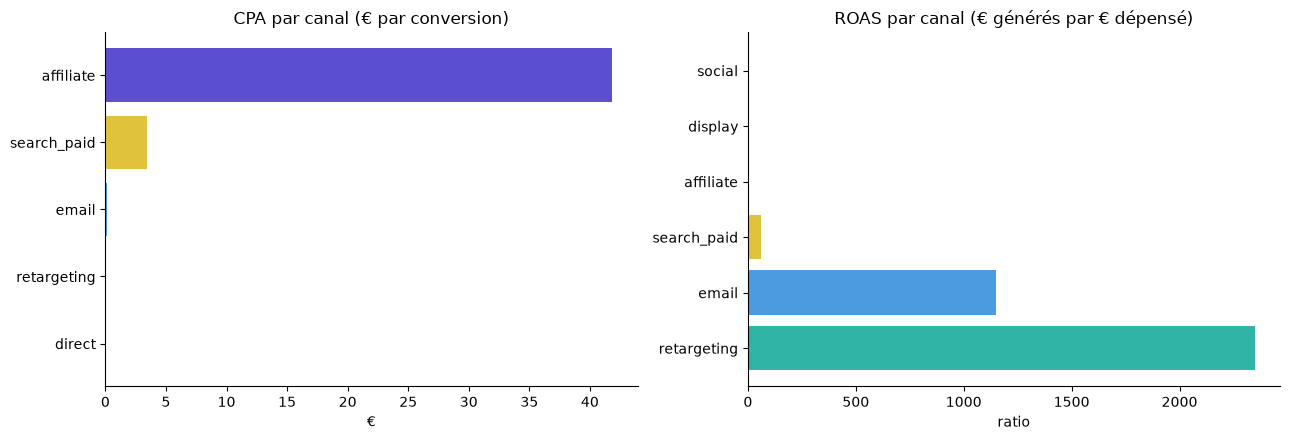

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

order_cpa = kpi["CPA"].replace(np.inf, np.nan).sort_values().index
axes[0].barh(order_cpa, kpi.loc[order_cpa, "CPA"].replace(np.inf, np.nan),
             color=[CHANNEL_COLORS[c] for c in order_cpa])
axes[0].set_title("CPA par canal (€ par conversion)")
axes[0].set_xlabel("€")

order_roas = kpi["ROAS"].replace(np.inf, np.nan).sort_values(ascending=False).index
axes[1].barh(order_roas, kpi.loc[order_roas, "ROAS"].replace(np.inf, np.nan),
             color=[CHANNEL_COLORS[c] for c in order_roas])
axes[1].set_title("ROAS par canal (€ générés par € dépensé)")
axes[1].set_xlabel("ratio")

plt.tight_layout()
plt.show()

### Le display ne se juge pas sur sa conversion directe

`display` a un ROAS de 0 et un CPA infini dans ce tableau — littéralement le pire canal si on s'arrête là. Mais
un utilisateur qui voit une bannière display sans cliquer, puis achète trois semaines plus tard après un clic sur
une pub retargeting, **doit une partie de sa décision d'achat au display**, même si le modèle "dernier clic"
utilisé ici pour calculer `converted` ne lui attribue rien. Juger le display uniquement sur ces métriques revient
à le classer comme sans valeur, alors qu'on n'a tout simplement pas la bonne métrique pour capturer son rôle
(exposition / notoriété plutôt que closing). **Cette question est développée en détail avec les données de
position dans le parcours dans `TP3_Attribution.ipynb`.**

### `primary_channel` de `campaigns.csv` : le canal le plus performant, ou autre chose ?

In [8]:
print("primary_channel par campagne :")
print(campaigns[["campaign_name", "primary_channel"]])

print("\nRang de chaque primary_channel dans nos classements (1 = meilleur) :")
for _, row in campaigns[["campaign_name", "primary_channel"]].drop_duplicates("primary_channel").iterrows():
    ch = row["primary_channel"]
    rang_cpa = list(kpi["CPA"].sort_values().index).index(ch) + 1
    rang_roas = list(kpi["ROAS"].sort_values(ascending=False).index).index(ch) + 1
    rang_conv = list(kpi["taux_conversion_%"].sort_values(ascending=False).index).index(ch) + 1
    print(f"  {ch:15s} → rang CPA: {rang_cpa}/7, rang ROAS: {rang_roas}/7, rang taux conversion: {rang_conv}/7")

primary_channel par campagne :
    campaign_name primary_channel
0  Back_to_School          social
1    Black_Friday         display
2   Spring_Launch         display
3     Summer_Sale         display
4       Valentine         display
5    Winter_Promo         display

Rang de chaque primary_channel dans nos classements (1 = meilleur) :
  social          → rang CPA: 7/7, rang ROAS: 7/7, rang taux conversion: 7/7
  display         → rang CPA: 6/7, rang ROAS: 6/7, rang taux conversion: 6/7


**Non : `primary_channel` ne désigne pas le canal le plus performant.** C'est `display` ou `social` pour les
**6 campagnes sur 6** — précisément les deux canaux qui ont un ROAS de 0 et un CPA infini dans notre classement.
Ils occupent les deux dernières places (rangs 6/7 et 7/7) sur CPA, ROAS et taux de conversion — leur ordre exact
entre eux deux n'a pas de sens (les deux sont à égalité parfaite, CPA infini et ROAS nul, le tri ne fait que
départager arbitrairement une égalité), mais le constat est sans ambiguïté : ce sont dans les deux cas les pires
canaux de notre classement. `primary_channel` désigne manifestement le canal qui porte **le plus de volume ou de
budget** dans la campagne (cohérent avec le fait que display et social concentrent 65 % des points de contact) —
un rôle d'ancrage ou de porte d'entrée de la campagne, pas un jugement de performance. Utiliser ce champ pour
décider où réinvestir serait une erreur d'interprétation.

## Vanity metrics

Parmi les colonnes brutes de `touchpoints.csv` — nombre de points de contact, nombre de clics, coût, conversions
— **prises isolément**, plusieurs sont de pures métriques de vanité :

- **Nombre de points de contact** seul ne dit rien : `display` en génère 316 530 (le plus de tous les canaux) et
  convertit directement zéro fois. Un gros volume d'exposition n'est pas un indicateur de performance.
- **Nombre de clics** seul est tout aussi trompeur : `social` a un CTR de 45 % (population raisonnable), mais
  zéro conversion directe elle non plus — cliquer n'est pas acheter.
- **Coût seul** ne renseigne sur rien sans le rapporter à un résultat : `affiliate` dépense 1,13 M€ (84 % du
  budget), ce qui semble énorme, mais ne dit ni si c'est efficace ni gaspillé sans le mettre en regard des
  conversions ou du revenu généré.
- **Nombre de conversions seul** ignore le coût qu'il a fallu pour les obtenir : `affiliate` a le plus de
  conversions absolues (26 979) mais aussi le CAC le plus élevé.

**Ce qui transforme ces métriques de vanité en KPI, c'est leur mise en ratio les unes par rapport aux autres** :
clics / points de contact = CTR (qualité de l'accroche), conversions / points de contact = taux de conversion
(qualité du ciblage), coût / conversions = CPA (efficience), revenu / coût = ROAS (rentabilité). Une métrique
devient un KPI quand elle est rapportée à un effort ou un objectif, jamais en valeur absolue isolée.

## Pour aller plus loin (optionnel) — CLTV et ratio LTV:CAC par canal

Le CAC ne dit pas si un canal est *rentable à terme* — un CAC élevé peut être un bon investissement si les
clients acquis via ce canal ont une valeur de vie (CLTV) élevée. On estime la CLTV avec la méthode simplifiée du
cours : `Panier moyen × Fréquence d'achat annualisée × Durée de vie estimée × Marge assumée`.

**Limite à documenter avant de commencer :** les campagnes ne couvrent qu'environ un an (été 2025 – été 2026),
donc tous les "nouveaux clients" de ce TP ont par construction une ancienneté courte. Annualiser leur fréquence
d'achat sur une fenêtre aussi courte **surestime** mécaniquement leur rythme d'achat réel (un client avec 1 achat
en 35 jours donne une fréquence annualisée de ~10/an, ce qui n'est pas tenable dans la durée). Les chiffres
ci-dessous sont donc des ordres de grandeur, pas des CLTV fiables au sens strict.

In [9]:
# durée de vie via le taux de rétention global de la base (Jour 2 : 70,3 % des clients ont >= 2 commandes)
transactions["is_fee_or_adjustment"] = transactions["category"].eq("Frais")
product_sales = transactions[
    (~transactions["is_fee_or_adjustment"]) & (transactions["quantity"] > 0) & (transactions["unit_price"] > 0)
].copy()
snapshot_date = transactions["invoice_date"].max()

sales_id = product_sales.dropna(subset=["customer_id"]).copy()
sales_id["customer_id"] = sales_id["customer_id"].astype(int)
rfm = sales_id.groupby("customer_id").agg(
    frequency=("invoice_id", "nunique"),
    monetary=("line_total", "sum"),
    first_purchase_recalc=("invoice_date", "min"),
).reset_index()
rfm["tenure_years"] = ((snapshot_date - rfm["first_purchase_recalc"]).dt.days / 365).clip(lower=30 / 365)
rfm["avg_basket"] = rfm["monetary"] / rfm["frequency"]
rfm["freq_per_year"] = rfm["frequency"] / rfm["tenure_years"]

retention_rate = (rfm["frequency"] >= 2).mean()
duree_vie = 1 / (1 - retention_rate)
MARGE_ASSUMEE = 0.35  # hypothèse : marge brute typique du DTC cosmétique, non fournie dans les données

print(f"Taux de rétention global (>= 2 commandes) : {retention_rate*100:.1f} %")
print(f"Durée de vie estimée : {duree_vie:.2f} périodes (années)")
print(f"Marge assumée : {MARGE_ASSUMEE*100:.0f} % (hypothèse, non fournie par les données)")

new_customers_ids = conversions.loc[conversions["is_first_purchase"], ["customer_id", "channel"]].drop_duplicates()
rfm_new = rfm.merge(new_customers_ids, on="customer_id", how="inner")

ltv_by_channel = rfm_new.groupby("channel").agg(n=("customer_id", "count"), avg_basket=("avg_basket", "mean"),
                                                  freq_per_year=("freq_per_year", "mean"))
ltv_by_channel["LTV"] = ltv_by_channel["avg_basket"] * ltv_by_channel["freq_per_year"] * duree_vie * MARGE_ASSUMEE
ltv_by_channel["CAC"] = kpi.loc[ltv_by_channel.index, "CAC"]
ltv_by_channel["LTV:CAC"] = ltv_by_channel["LTV"] / ltv_by_channel["CAC"]
ltv_by_channel.round(2)

Taux de rétention global (>= 2 commandes) : 70.3 %
Durée de vie estimée : 3.37 périodes (années)
Marge assumée : 35 % (hypothèse, non fournie par les données)


,n,avg_basket,freq_per_year,LTV,CAC,LTV:CAC
channel,,,,,,
affiliate,492,641.56,10.37,7846.45,2289.61,3.43
direct,269,513.92,8.41,5094.03,0.00,inf
email,252,591.50,7.21,5028.59,8.98,559.90
retargeting,424,541.87,10.38,6634.08,4.44,1492.77
search_paid,259,647.71,9.91,7571.73,182.49,41.49


**Un bon CAC n'est pas toujours un bon canal, et inversement.** `affiliate` a de loin le pire CAC (2 290 €)
mais franchit tout juste le seuil de rentabilité usuel (LTV ≥ 3× CAC, cf. cours) avec un ratio de **3,4** — les
clients qu'il ramène dépensent nettement plus par la suite (avg_basket le plus élevé de tous les canaux), ce qui
compense en partie son coût élevé. `search_paid`, avec un CAC bien plus raisonnable (182 €), affiche un ratio
LTV:CAC beaucoup plus confortable (~41). `retargeting` et `email`, déjà en tête sur CAC/ROAS, restent également
très largement au-dessus du seuil de 3×. `direct`, avec un CAC nul, donne un ratio infini — peu informatif, pour
la même raison que plus haut (ce n'est pas un levier sur lequel on peut décider d'investir davantage).

**Le classement ne change donc pas radicalement** une fois la CLTV prise en compte : les canaux déjà bons sur
CAC/ROAS (retargeting, email, direct) le restent largement sur LTV:CAC. La vraie bascule concerne `affiliate` :
son CAC élevé semblait le pénaliser fortement, mais sa valeur de vie plus élevée le rend malgré tout rentable —
juste avec une marge de sécurité beaucoup plus faible que les autres canaux payants.

## Conclusion — ce que le CMO doit retenir

Il n'existe pas de "meilleur canal" unique : le classement change selon qu'on regarde le coût par conversion, le
retour sur investissement ou le taux de conversion, parce que ces métriques répondent à des questions
différentes. Deux points à retenir en priorité :

1. **`display` et `social` ne doivent pas être coupés sur la seule base de ces KPIs** — leur ROAS de 0 reflète un
   modèle d'attribution (dernier clic) qui ne capture pas leur rôle réel dans le parcours. Voir
   `TP3_Attribution.ipynb` pour la suite de cette analyse.
2. **`primary_channel` (toujours display ou social) ne doit pas guider les décisions budgétaires** — c'est un
   indicateur de volume, pas de performance ; les décisions de réallocation doivent s'appuyer sur le tableau de
   KPIs construit ici, pas sur ce champ.